Nate Miller

Group 1: emily, isaac, jonathan

Group 2: cesar, zoell, molly

In [1]:
# Package Imports - copy and paste
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

C:\Users\natha\anaconda3\Lib\site-packages\kaleido\__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [3]:
# Load the data - copy and paste
file_location = 'https://joannabieri.com/introdatascience/data/lego_sample.csv'
DF = pd.read_csv(file_location)

In [5]:
# Look at the data - copy and paste
show(DF)

Loading ITables v2.5.2 from the internet... (need help?)


Problem 1

In [9]:
#A
DF.shape

(75, 14)

there are 14 variables and 75 observations

In [18]:
#B
DF.columns #names of variables

Index(['item_number', 'set_name', 'theme', 'pieces', 'price', 'amazon_price',
       'year', 'ages', 'pages', 'minifigures', 'packaging', 'weight',
       'unique_pieces', 'size'],
      dtype='object')

#C

item_number: Categorical, nominal (ID code)

set_name: Categorical, nominal (name label)

theme: Categorical, nominal (theme category)

pieces: Numerical, discrete (count of pieces)

price: Numerical, continuous (retail price)

amazon_price: Numerical, continuous (amazon price) 

year: Numerical, discrete (year released)

ages: Categorical, ordinal (age ranges with natural order)

pages: Numerical, discrete (count of pages in instructions)

minifigures: Numerical, discrete (count of minifigures)

packaging: Categorical, nominal (box, plastic box, etc.)

weight: Numerical, continuous (kg/lb measurement)

unique_pieces: Numerical, discrete (count of unique piece types)

size: Categorical, nominal (Large/Small)


In [23]:
#D
DF.describe()

,item_number,pieces,price,amazon_price,year,pages,minifigures,unique_pieces
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,65.000000,75.000000
mean,37498.493333,196.453333,32.136667,39.393733,2019.053333,73.213333,2.615385,96.666667
std,20461.267542,213.914121,27.747263,33.301259,0.820239,76.949842,2.133749,89.471018
min,10859.000000,6.000000,4.990000,6.290000,2018.000000,1.000000,1.000000,5.000000
25%,10916.500000,37.000000,9.990000,17.980000,2018.000000,14.000000,1.000000,30.000000
50%,41378.000000,93.000000,19.990000,29.990000,2019.000000,44.000000,2.000000,61.000000
75%,60193.000000,323.500000,39.990000,53.935000,2020.000000,116.000000,3.000000,151.000000
max,60267.000000,897.000000,149.990000,184.990000,2020.000000,389.000000,15.000000,411.000000


from describe we can see that the average price is higher on amazon, each set has about 97 unique pieces in it, only 65 out of the 70 sets contain minifigures, and on average a lego set will have about 196 pieces

Problem 2

In [28]:
#A
DF[['item_number', 'set_name', 'theme', 'ages', 'size']]
#the only categorical variable I left out was packaging because that doesn't have to do with the lego set itself

,item_number,set_name,theme,ages,size
0,10859,My First Ladybird,DUPLO®,Ages_1½-3,Large
1,10860,My First Race Car,DUPLO®,Ages_1½-3,Large
2,10862,My First Celebration,DUPLO®,Ages_1½-3,Large
3,10864,Large Playground Brick Box,DUPLO®,Ages_2-5,Large
4,10867,Farmers' Market,DUPLO®,Ages_2-5,Large
...,...,...,...,...,...
70,60251,Monster Truck,City,Ages_5+,Small
71,60252,Construction Bulldozer,City,Ages_4+,Small
72,60258,Tuning Workshop,City,Ages_6+,Small
73,60266,Ocean Exploration Ship,City,Ages_7+,Small


In [51]:
#B
{'item_number': DF['item_number'].value_counts(),
    'set_name': DF['set_name'].value_counts(),
    'theme': DF['theme'].value_counts(),
    'ages': DF['ages'].value_counts(),
    'size': DF['size'].value_counts()}


{'item_number': item_number
 10859    1
 60202    1
 60183    1
 60182    1
 60172    1
         ..
 10929    1
 10928    1
 10927    1
 10926    1
 60267    1
 Name: count, Length: 75, dtype: int64,
 'set_name': set_name
 My First Ladybird                   1
 People Pack - Outdoor Adventures    1
 Heavy Cargo Transport               1
 Pickup & Caravan                    1
 Dirt Road Pursuit                   1
                                    ..
 Modular Playhouse                   1
 Bakery                              1
 Pizza Stand                         1
 Bedroom                             1
 Safari Off-Roader                   1
 Name: count, Length: 75, dtype: int64,
 'theme': theme
 DUPLO®     25
 Friends    25
 City       25
 Name: count, dtype: int64,
 'ages': ages
 Ages_6+      20
 Ages_5+      13
 Ages_2+      10
 Ages_2-5      8
 Ages_5-12     7
 Ages_6-12     5
 Ages_1½+      4
 Ages_1½-3     3
 Ages_4+       2
 Ages_7+       2
 Ages_8+       1
 Name: count, dtype

Item number and set name are both unique for each set. There are 3 different themes with exactly 25 sets in each theme. there are 11 age categories with 6+ being the most common one. There are two sizes, with 50 smalls and 25 large sets

Problem 3

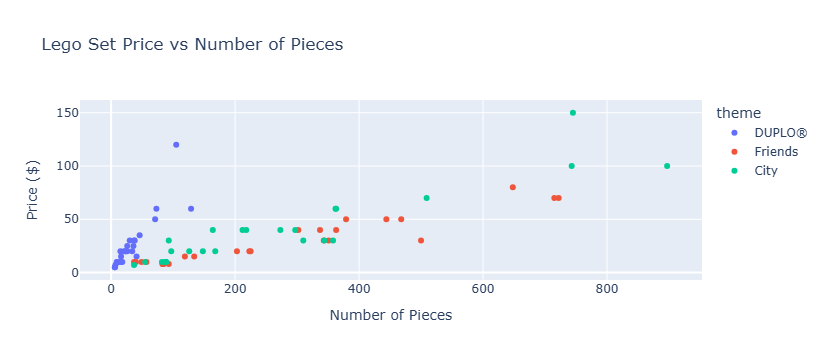

In [57]:
#A
px.scatter(DF, 
           x='pieces', 
           y='price', 
           color='theme', 
           hover_data=['set_name'],
           labels={'pieces':'Number of Pieces', 'price':'Price ($)'},
           title='Lego Set Price vs Number of Pieces')

#B

Do the more expensive sets have more pieces? Yes the more expensive sets typically have more pieces, with the exeption of a couple DUPLO sets

What is the most expensive se?
The ocean exploration ship is the most expensive at 149.99


Are there any differences between the them?
yes, DUPLO has less peices but is also generally cheaper, friends and city follow a similar pattern with city appearing just slightly more expensive on average for similar numbers of piecess?

In [65]:
#A
DF['price_diff'] = DF['amazon_price'] - DF['price']

In [67]:
#B
DF.groupby('theme')['price_diff'].describe()

,count,mean,std,min,25%,50%,75%,max
theme,,,,,,,,
City,25.0,5.3996,15.243677,-13.99,-4.01,-1.00,12.00,39.96
DUPLO®,25.0,7.3924,16.996152,-5.00,-2.00,0.00,11.01,69.00
Friends,25.0,8.9792,24.047927,-9.99,-0.04,3.96,8.94,115.00


from this describe, we see that city has the smallest difference between retail and amazon, while friends has the greatest difference. overall, the amazon prices are typically 5-9 dollars more than the retail prices, but all 3 themes have sets that are cheaper on amazon

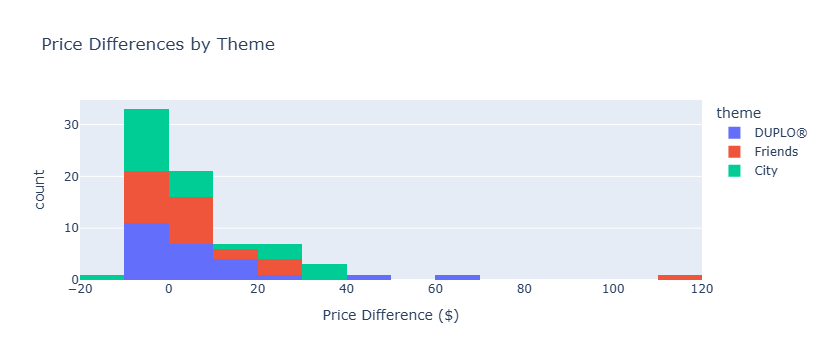

In [76]:
#C
px.histogram(DF, 
             x='price_diff', 
             color='theme',
             labels={'price_diff':'Price Difference ($)'},
             title='Price Differences by Theme')

Problem 5

In [79]:
#A
DF[DF['price'] == DF['price'].max()]

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_diff
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.0


this set is the most expensive retail set, it has almost 4x as many pieces and minifigures as an average set, and has over 300 unique pieces. The price is the same for both retail and amazon 

In [82]:
#B
DF[DF['amazon_price'] == DF['amazon_price'].max()]

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_diff
28,41340,Friendship House,Friends,722,69.99,184.99,2018,Ages_6-12,164,3.0,Box,1.14Kg (2.51 lb),309,Small,115.0


this is the most expensive amazon set at 184.99, it has over 700 pieces and 300 unique pieces. it costs 115 more dollars to buy it on amazon vs retail

In [86]:
#C
DF[(DF['price'] > 100) | (DF['amazon_price'] > 100)]

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_diff
7,10875,Cargo Train,DUPLO®,105,119.99,128.95,2018,Ages_2-5,64,3.0,Box,2.86Kg (6.31 lb),68,Large,8.96
28,41340,Friendship House,Friends,722,69.99,184.99,2018,Ages_6-12,164,3.0,Box,1.14Kg (2.51 lb),309,Small,115.00
73,60266,Ocean Exploration Ship,City,745,149.99,149.99,2020,Ages_7+,229,8.0,Box,2.28Kg (5.03 lb),314,Small,0.00


other than the previous two, there is only 1 other set over 100 dollars, it is the cargo train set with only 100 pieces, but it is a large DUPLO set

Problem 6

In [93]:
#A
DF.groupby('year')['price'].mean()

year
2018    28.772609
2019    28.670000
2020    38.212222
Name: price, dtype: float64

the price remained consistent in 2018 and 2019 but saw a big jump in 2020 likely due to higher demand with more people stuck at home

In [95]:
#B
DF.groupby('year')['pieces'].mean()

year
2018    157.913043
2019    193.120000
2020    232.370370
Name: pieces, dtype: float64

over these 3 years the average number of pieces saw a steady increase of almost 40 pieces per year

In [98]:
#C
DF[DF['minifigures'] == DF['minifigures'].max()]

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_diff
56,60202,People Pack - Outdoor Adventures,City,164,39.99,69.99,2018,Ages_5-12,64,15.0,Box,0.29Kg (0.64 lb),128,Small,30.0


In [100]:
DF[DF['minifigures'].isna() | (DF['minifigures'] == 0)]

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_diff
0,10859,My First Ladybird,DUPLO®,6,4.99,16.00,2018,Ages_1½-3,9,NaN,Box,NaN,5,Large,11.01
1,10860,My First Race Car,DUPLO®,6,4.99,9.45,2018,Ages_1½-3,9,NaN,Box,0.13Kg (0.29 lb),6,Large,4.46
2,10862,My First Celebration,DUPLO®,41,14.99,39.89,2018,Ages_1½-3,9,NaN,Box,NaN,18,Large,24.90
5,10870,Farm Animals,DUPLO®,16,9.99,9.99,2018,Ages_2-5,8,NaN,Box,NaN,13,Large,0.00
10,10882,Train Tracks,DUPLO®,23,19.99,17.99,2018,Ages_2-5,16,NaN,Box,0.66Kg (1.45 lb),9,Large,-2.00
11,10885,My First Fun Puzzle,DUPLO®,15,19.99,19.55,2019,Ages_1½+,9,NaN,NaN,NaN,15,Large,-0.44
12,10886,My First Car Creations,DUPLO®,34,19.99,16.00,2019,Ages_1½+,10,NaN,NaN,0.64Kg (1.41 lb),31,Large,-3.99
14,10904,Baby Animals,DUPLO®,9,9.99,21.11,2019,Ages_2+,8,NaN,Box,NaN,9,Large,11.12
19,10918,Tow Truck,DUPLO®,7,6.99,6.29,2020,Ages_1½+,3,NaN,Box with backing card,NaN,7,Large,-0.70
29,41353,Friends Advent Calendar,Friends,500,29.99,34.00,2018,Ages_6-12,4,NaN,Box,NaN,202,Small,4.01


People Pack - Outdoor Adventures has the most minifigures with 15 and there are 10 sets with no minifigures

Problem 7

defining a good deal:
1. age-appropriate
2. best price per piece value
3. at least one minifig
4. amazon prices because it's the most widely accessible

In [111]:
# Filter out unwanted ages
age_DF = DF[
    (DF['ages'] != '2-5') &
    (DF['ages'] != '1.5-3') &
    (DF['ages'] != '7+') &
    (DF['ages'] != '8+') ]

# Make sure it has a minifig
age_DF = age_DF[age_DF['minifigures'] >= 1]

# Calculate price per piece
age_DF['price_per_piece'] = age_DF['amazon_price'] / age_DF['pieces']

# Sort by price per piece to find the best deal
best_deals = age_DF.sort_values('price_per_piece').head(5)

# Show list
best_deals

,item_number,set_name,theme,pieces,price,amazon_price,year,ages,pages,minifigures,packaging,weight,unique_pieces,size,price_diff,price_per_piece
35,41374,Andrea's Pool Party,Friends,468,49.99,40.00,2019,Ages_6+,112,2.0,Box,NaN,221,Small,-9.99,0.085470
39,41387,Olivia's Summer Heart Box,Friends,93,7.99,7.99,2019,Ages_6+,40,2.0,Other,NaN,48,Small,0.00,0.085914
37,41378,Dolphins Rescue Mission,Friends,363,39.99,31.67,2019,Ages_6+,116,2.0,Box,NaN,192,Small,-8.32,0.087245
48,41427,Emma's Fashion Shop,Friends,343,29.99,29.95,2020,Ages_6+,112,2.0,Box,NaN,152,Small,-0.04,0.087318
34,41369,Mia's House,Friends,715,69.99,62.99,2019,Ages_6+,192,3.0,NaN,1.12Kg (2.47 lb),274,Small,-7.00,0.088098


according to these criteria, Andrea's pool party is the best deal with 468 pieces, and 2 minigiures for 40 dollars, it also includes 221 unique pieces